# Product Sales Forecasting

# Business Problem Statement

## Problem Statement
In the retail industry, inaccurate sales forecasting can lead to major business issues:

* Overstocking increases storage and inventory costs
* Understocking leads to lost sales and poor customer satisfaction
* Poor planning affects staffing, promotions, logistics, and revenue forecasting

The goal of this project is to build a machine learning model that predicts daily sales using historical store and product-level data. The predictions can help businesses make better inventory, marketing, and operational decisions.

# Dataset Overview and Data cleaning

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [9]:
df = pd.read_csv('/content/drive/MyDrive/TRAIN.csv')

display(df.head())

,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,7011.84
1,T1000002,253,S4,L2,R1,2018-01-01,1,Yes,60,51789.12
2,T1000003,252,S3,L2,R1,2018-01-01,1,Yes,42,36868.20
3,T1000004,251,S2,L3,R1,2018-01-01,1,Yes,23,19715.16
4,T1000005,250,S2,L3,R4,2018-01-01,1,Yes,62,45614.52


In [10]:
# Display the column names and their data types
print("Column names and data types:")
display(df.info())

# Get a statistical summary of the numerical columns
print("\nStatistical summary of numerical columns:")
display(df.describe())

# Check for missing values
print("\nMissing values per column:")
display(df.isnull().sum())

# Get the number of unique values in each column
print("\nNumber of unique values per column:")
display(df.nunique())

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188340 entries, 0 to 188339
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ID             188340 non-null  object 
 1   Store_id       188340 non-null  int64  
 2   Store_Type     188340 non-null  object 
 3   Location_Type  188340 non-null  object 
 4   Region_Code    188340 non-null  object 
 5   Date           188340 non-null  object 
 6   Holiday        188340 non-null  int64  
 7   Discount       188340 non-null  object 
 8   #Order         188340 non-null  int64  
 9   Sales          188340 non-null  float64
dtypes: float64(1), int64(3), object(6)
memory usage: 14.4+ MB


None


Statistical summary of numerical columns:


,Store_id,Holiday,#Order,Sales
count,188340.000000,188340.000000,188340.000000,188340.000000
mean,183.000000,0.131783,68.205692,42784.327982
std,105.366308,0.338256,30.467415,18456.708302
min,1.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,48.000000,30426.000000
50%,183.000000,0.000000,63.000000,39678.000000
75%,274.000000,0.000000,82.000000,51909.000000
max,365.000000,1.000000,371.000000,247215.000000



Missing values per column:


,0
ID,0
Store_id,0
Store_Type,0
Location_Type,0
Region_Code,0
Date,0
Holiday,0
Discount,0
#Order,0
Sales,0



Number of unique values per column:


,0
ID,188340
Store_id,365
Store_Type,4
Location_Type,5
Region_Code,4
Date,516
Holiday,2
Discount,2
#Order,299
Sales,47422


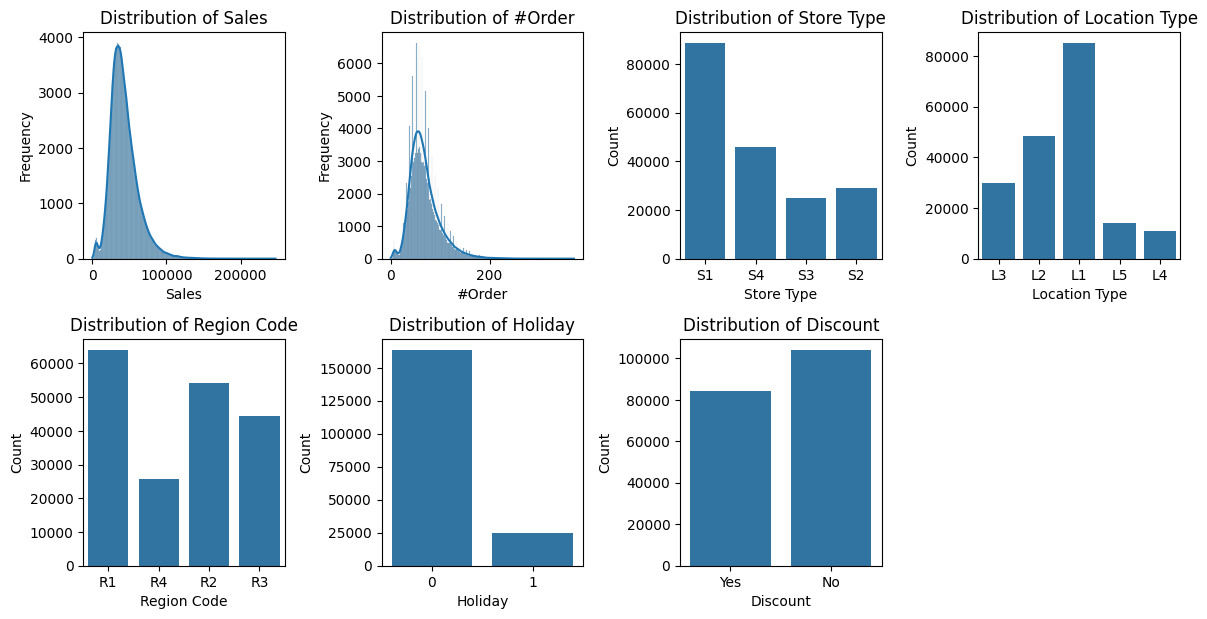

In [11]:
# Create subplots for better visualization
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(12, 12))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Distribution of 'Sales'
sns.histplot(df['Sales'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')

# Distribution of '#Order'
sns.histplot(df['#Order'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of #Order')
axes[1].set_xlabel('#Order')
axes[1].set_ylabel('Frequency')

# Countplot of 'Store_Type'
sns.countplot(x='Store_Type', data=df, ax=axes[2])
axes[2].set_title('Distribution of Store Type')
axes[2].set_xlabel('Store Type')
axes[2].set_ylabel('Count')

# Countplot of 'Location_Type'
sns.countplot(x='Location_Type', data=df, ax=axes[3])
axes[3].set_title('Distribution of Location Type')
axes[3].set_xlabel('Location Type')
axes[3].set_ylabel('Count')

# Countplot of 'Region_Code'
sns.countplot(x='Region_Code', data=df, ax=axes[4])
axes[4].set_title('Distribution of Region Code')
axes[4].set_xlabel('Region Code')
axes[4].set_ylabel('Count')

# Countplot of 'Holiday'
sns.countplot(x='Holiday', data=df, ax=axes[5])
axes[5].set_title('Distribution of Holiday')
axes[5].set_xlabel('Holiday')
axes[5].set_ylabel('Count')

# Countplot of 'Discount'
sns.countplot(x='Discount', data=df, ax=axes[6])
axes[6].set_title('Distribution of Discount')
axes[6].set_xlabel('Discount')
axes[6].set_ylabel('Count')

# Remove any unused subplots
for i in range(7, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

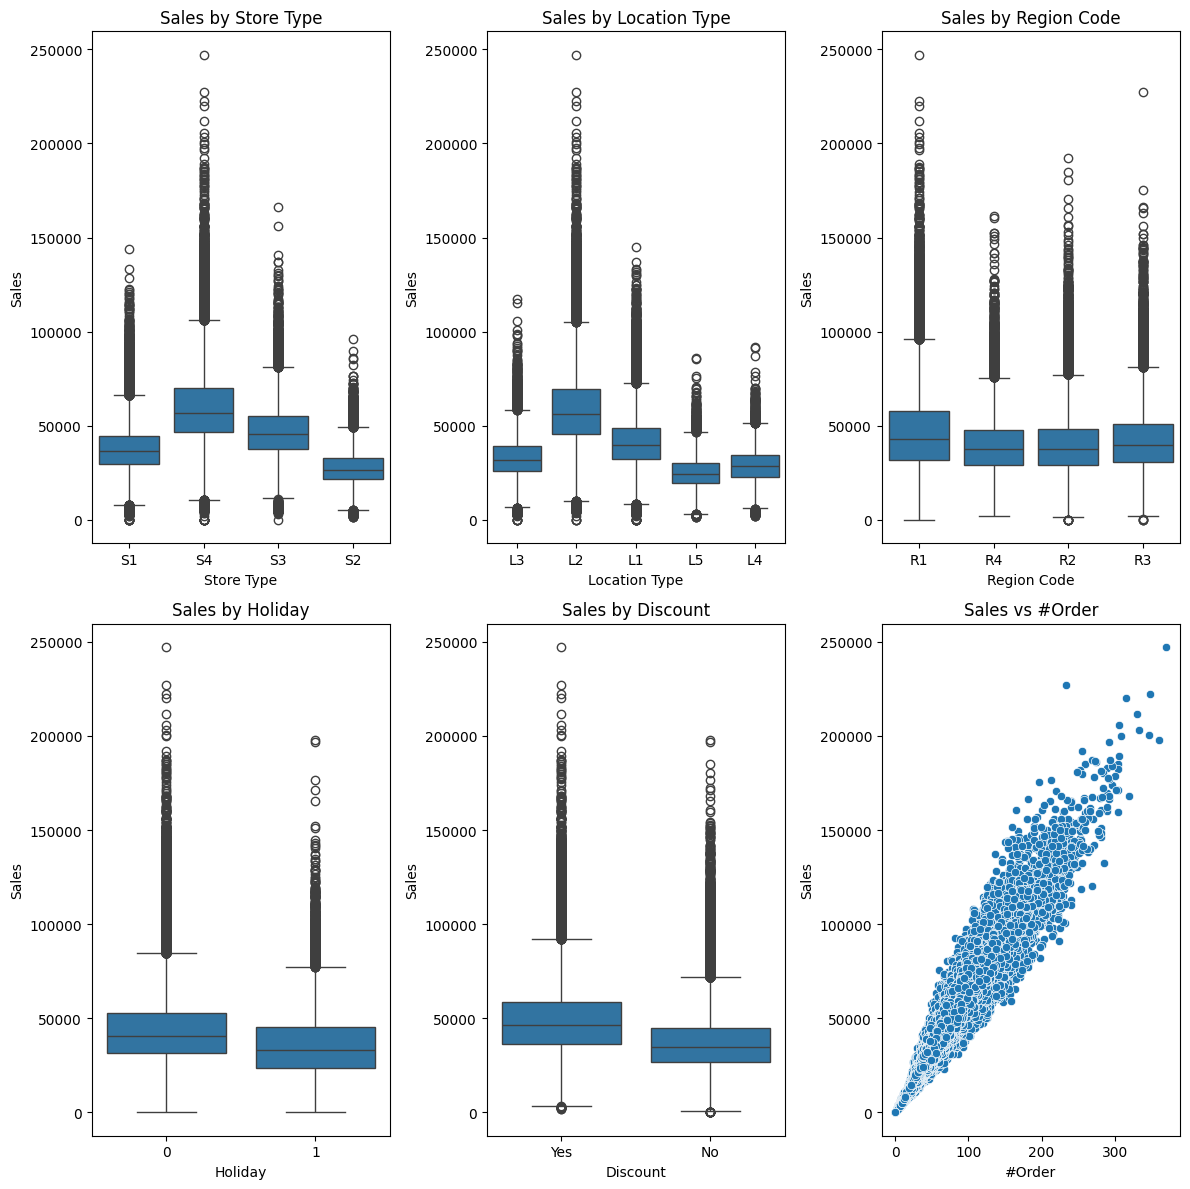

In [12]:
# Create subplots for bivariate analysis
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 12))
axes = axes.flatten()

# Boxplot of Sales vs Store Type
sns.boxplot(x='Store_Type', y='Sales', data=df, ax=axes[0])
axes[0].set_title('Sales by Store Type')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Sales')

# Boxplot of Sales vs Location Type
sns.boxplot(x='Location_Type', y='Sales', data=df, ax=axes[1])
axes[1].set_title('Sales by Location Type')
axes[1].set_xlabel('Location Type')
axes[1].set_ylabel('Sales')

# Boxplot of Sales vs Region Code
sns.boxplot(x='Region_Code', y='Sales', data=df, ax=axes[2])
axes[2].set_title('Sales by Region Code')
axes[2].set_xlabel('Region Code')
axes[2].set_ylabel('Sales')

# Boxplot of Sales vs Holiday
sns.boxplot(x='Holiday', y='Sales', data=df, ax=axes[3])
axes[3].set_title('Sales by Holiday')
axes[3].set_xlabel('Holiday')
axes[3].set_ylabel('Sales')

# Boxplot of Sales vs Discount
sns.boxplot(x='Discount', y='Sales', data=df, ax=axes[4])
axes[4].set_title('Sales by Discount')
axes[4].set_xlabel('Discount')
axes[4].set_ylabel('Sales')

# Scatter plot of Sales vs #Order
sns.scatterplot(x='#Order', y='Sales', data=df, ax=axes[5])
axes[5].set_title('Sales vs #Order')
axes[5].set_xlabel('#Order')
axes[5].set_ylabel('Sales')

plt.tight_layout()
plt.show()

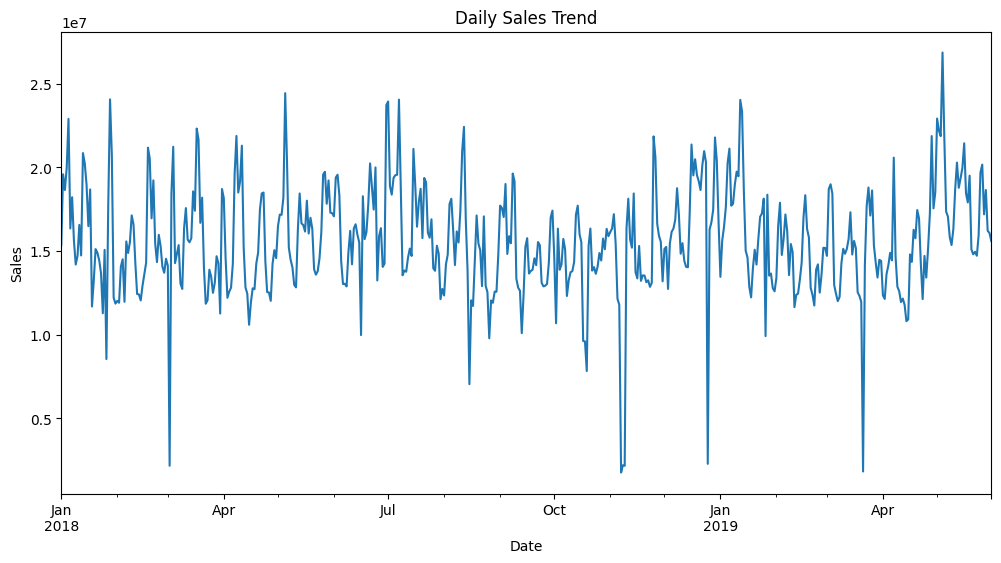

In [13]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Set 'Date' as the index for time series analysis
df.set_index('Date', inplace=True)

# Resample the data to get daily sales and visualize the trend
daily_sales = df['Sales'].resample('D').sum()

plt.figure(figsize=(12, 6))
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

# You can also resample to other frequencies, e.g., monthly sales
# monthly_sales = df['Sales'].resample('M').sum()
# plt.figure(figsize=(12, 6))
# monthly_sales.plot()
# plt.title('Monthly Sales Trend')
# plt.xlabel('Date')
# plt.ylabel('Sales')
# plt.show()

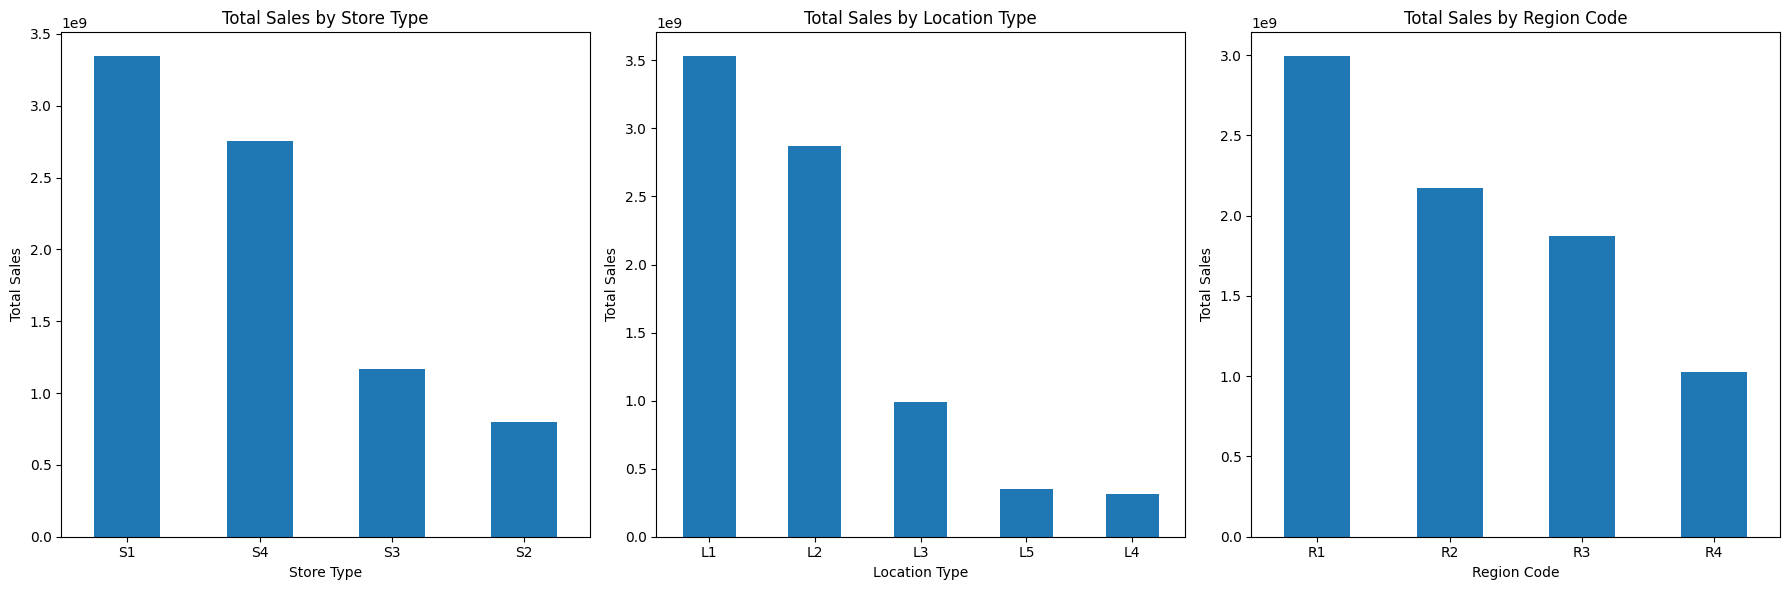

In [14]:
# Group by 'Store_Type' and calculate sum of 'Sales'
sales_by_store_type = df.groupby('Store_Type')['Sales'].sum().sort_values(ascending=False)

# Group by 'Location_Type' and calculate sum of 'Sales'
sales_by_location_type = df.groupby('Location_Type')['Sales'].sum().sort_values(ascending=False)

# Group by 'Region_Code' and calculate sum of 'Sales'
sales_by_region_code = df.groupby('Region_Code')['Sales'].sum().sort_values(ascending=False)

# Create subplots for bar charts
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
axes = axes.flatten()

# Bar chart for Sales by Store Type
sales_by_store_type.plot(kind='bar', ax=axes[0])
axes[0].set_title('Total Sales by Store Type')
axes[0].set_xlabel('Store Type')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=0)

# Bar chart for Sales by Location Type
sales_by_location_type.plot(kind='bar', ax=axes[1])
axes[1].set_title('Total Sales by Location Type')
axes[1].set_xlabel('Location Type')
axes[1].set_ylabel('Total Sales')
axes[1].tick_params(axis='x', rotation=0)

# Bar chart for Sales by Region Code
sales_by_region_code.plot(kind='bar', ax=axes[2])
axes[2].set_title('Total Sales by Region Code')
axes[2].set_xlabel('Region Code')
axes[2].set_ylabel('Total Sales')
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

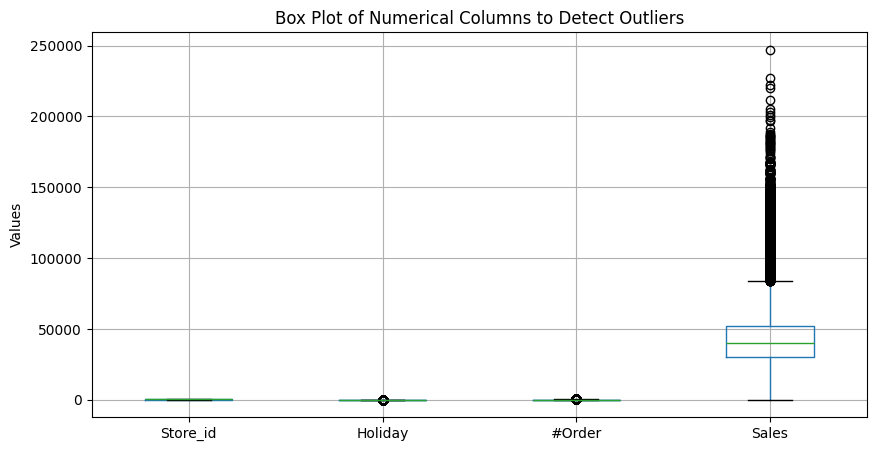

In [15]:
# Select numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=np.number).columns

# Create box plots for numerical columns to visualize outliers
plt.figure(figsize=(10, 5))
df[numerical_cols].boxplot()
plt.title('Box Plot of Numerical Columns to Detect Outliers')
plt.ylabel('Values')
plt.show()


## Data cleaning

### Subtask:
Check for and handle missing values, duplicates, and inconsistencies.


**Reasoning**:
Check for missing values and duplicates in the dataframe.



In [16]:
# Check for missing values
print("Missing values before cleaning:")
display(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows before cleaning:")
display(df.duplicated().sum())

# Remove duplicate rows if any
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("\nDuplicate rows removed.")

# Verify missing values and duplicates after cleaning
print("\nMissing values after cleaning:")
display(df.isnull().sum())

print("\nNumber of duplicate rows after cleaning:")
display(df.duplicated().sum())

Missing values before cleaning:


,0
ID,0
Store_id,0
Store_Type,0
Location_Type,0
Region_Code,0
Holiday,0
Discount,0
#Order,0
Sales,0



Number of duplicate rows before cleaning:


np.int64(0)


Missing values after cleaning:


,0
ID,0
Store_id,0
Store_Type,0
Location_Type,0
Region_Code,0
Holiday,0
Discount,0
#Order,0
Sales,0



Number of duplicate rows after cleaning:


np.int64(0)

# Hypothesis testing

T-test (sales_with_discount, sales_without_discount)

In [17]:
## Hypothesis testing
from scipy.stats import ttest_ind

# Separate sales data for days with and without discounts
sales_with_discount = df[df['Discount'] == 'Yes']['Sales']
sales_without_discount = df[df['Discount'] == 'No']['Sales']

# Perform independent samples t-test
ttest_result = ttest_ind(sales_with_discount, sales_without_discount)

# Print the results
print("Independent Samples t-test Results:")
print(f"Test Statistic: {ttest_result.statistic:.4f}")
print(f"P-value: {ttest_result.pvalue:.4f}")

# Interpret the results
alpha = 0.05
if ttest_result.pvalue < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between days with and without discounts.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in mean sales between days with and without discounts.")

Independent Samples t-test Results:
Test Statistic: 148.5785
P-value: 0.0000

Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between days with and without discounts.


T-test (sales_holiday, sales_non_holiday)

In [18]:
from scipy.stats import ttest_ind

# Separate sales data for holiday and non-holiday days
sales_holiday = df[df['Holiday'] == 1]['Sales']
sales_non_holiday = df[df['Holiday'] == 0]['Sales']

# Perform independent samples t-test
ttest_result_holiday = ttest_ind(sales_holiday, sales_non_holiday)

# Print the results
print("Independent Samples t-test Results (Holiday vs. Non-Holiday):")
print(f"Test Statistic: {ttest_result_holiday.statistic:.4f}")
print(f"P-value: {ttest_result_holiday.pvalue:.4f}")

# Interpret the results
alpha = 0.05
if ttest_result_holiday.pvalue < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between holiday and non-holiday days.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in mean sales between holiday and non-holiday days.")

Independent Samples t-test Results (Holiday vs. Non-Holiday):
Test Statistic: -67.9901
P-value: 0.0000

Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between holiday and non-holiday days.


ANOVA test (Sales by Store Type)

In [19]:
from scipy import stats

# Separate sales data for each store type
sales_s1 = df[df['Store_Type'] == 'S1']['Sales']
sales_s2 = df[df['Store_Type'] == 'S2']['Sales']
sales_s3 = df[df['Store_Type'] == 'S3']['Sales']
sales_s4 = df[df['Store_Type'] == 'S4']['Sales']

# Perform one-way ANOVA test
fvalue, pvalue = stats.f_oneway(sales_s1, sales_s2, sales_s3, sales_s4)

print("One-Way ANOVA Results (Sales by Store Type):")
print(f"F-statistic: {fvalue:.4f}")
print(f"P-value: {pvalue:.4f}")

# Interpret the results
alpha = 0.05
if pvalue < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between different store types.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in mean sales between different store types.")

One-Way ANOVA Results (Sales by Store Type):
F-statistic: 35123.6441
P-value: 0.0000

Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between different store types.


ANOVA test (Sales by Region Code)

In [20]:
from scipy import stats

# Separate sales data for each region code
sales_r1 = df[df['Region_Code'] == 'R1']['Sales']
sales_r2 = df[df['Region_Code'] == 'R2']['Sales']
sales_r3 = df[df['Region_Code'] == 'R3']['Sales']
sales_r4 = df[df['Region_Code'] == 'R4']['Sales']


# Perform one-way ANOVA test
fvalue, pvalue = stats.f_oneway(sales_r1, sales_r2, sales_r3, sales_r4)

print("One-Way ANOVA Results (Sales by Region Code):")
print(f"F-statistic: {fvalue:.4f}")
print(f"P-value: {pvalue:.4f}")

# Interpret the results
alpha = 0.05
if pvalue < alpha:
    print("\nConclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between different region codes.")
else:
    print("\nConclusion: Fail to reject the null hypothesis. There is no statistically significant difference in mean sales between different region codes.")

One-Way ANOVA Results (Sales by Region Code):
F-statistic: 1682.4255
P-value: 0.0000

Conclusion: Reject the null hypothesis. There is a statistically significant difference in mean sales between different region codes.


# Correlation

Correlation between Order and Sales

In [21]:
# Calculate Pearson correlation coefficient
pearson_corr = df['#Order'].corr(df['Sales'], method='pearson')
print(f"Pearson correlation between #Order and Sales: {pearson_corr:.4f}")

# Calculate Spearman correlation coefficient
spearman_corr = df['#Order'].corr(df['Sales'], method='spearman')
print(f"Spearman correlation between #Order and Sales: {spearman_corr:.4f}")

# Interpret the results (optional)
# A correlation coefficient close to 1 indicates a strong positive linear relationship
# A correlation coefficient close to -1 indicates a strong negative linear relationship
# A correlation coefficient close to 0 indicates a weak or no linear relationship
# The strength of the correlation can be interpreted using guidelines (e.g., 0.0-0.3 weak, 0.3-0.7 moderate, 0.7-1.0 strong)

Pearson correlation between #Order and Sales: 0.9416
Spearman correlation between #Order and Sales: 0.9377


Correlation Matrix

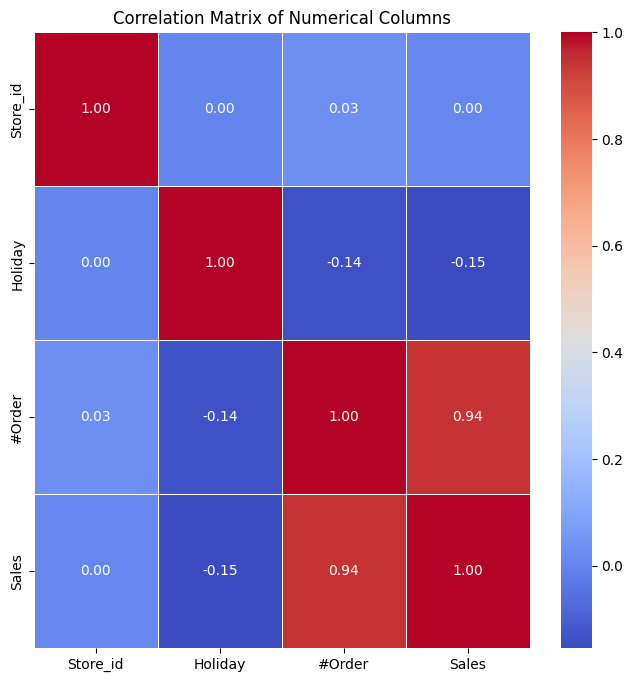

In [22]:
# Calculate the correlation matrix for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap of the correlation matrix
plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns')
plt.show()


# Feature engineering


Subtask:

Create new features from existing ones, such as time-based features from the 'Date' column or interaction terms.

**Reasoning**:
Extract time-based features from the 'Date' column and create new columns, also create indicators for start/end of month/year, and create interaction terms between categorical features and 'Discount'.



In [23]:
# Extract time-based features
df['Year'] = df.index.year
df['Month'] = df.index.month
df['Day'] = df.index.day
df['Dayofweek'] = df.index.dayofweek
df['Weekofyear'] = df.index.isocalendar().week.astype(int)

# Create day of month column
df['Dayofmonth'] = df.index.day

# Create start/end of month/year indicators
df['Is_month_start'] = df.index.is_month_start.astype(int)
df['Is_month_end'] = df.index.is_month_end.astype(int)
df['Is_year_start'] = df.index.is_year_start.astype(int)
df['Is_year_end'] = df.index.is_year_end.astype(int)

# Create interaction terms with 'Discount'
df['Store_Type_Discount'] = df['Store_Type'] + '_' + df['Discount']
df['Location_Type_Discount'] = df['Location_Type'] + '_' + df['Discount']

display(df.head())

,ID,Store_id,Store_Type,Location_Type,Region_Code,Holiday,Discount,#Order,Sales,Year,...,Day,Dayofweek,Weekofyear,Dayofmonth,Is_month_start,Is_month_end,Is_year_start,Is_year_end,Store_Type_Discount,Location_Type_Discount
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,T1000001,1,S1,L3,R1,1,Yes,9,7011.84,2018,...,1,0,1,1,1,0,1,0,S1_Yes,L3_Yes
2018-01-01,T1000002,253,S4,L2,R1,1,Yes,60,51789.12,2018,...,1,0,1,1,1,0,1,0,S4_Yes,L2_Yes
2018-01-01,T1000003,252,S3,L2,R1,1,Yes,42,36868.20,2018,...,1,0,1,1,1,0,1,0,S3_Yes,L2_Yes
2018-01-01,T1000004,251,S2,L3,R1,1,Yes,23,19715.16,2018,...,1,0,1,1,1,0,1,0,S2_Yes,L3_Yes
2018-01-01,T1000005,250,S2,L3,R4,1,Yes,62,45614.52,2018,...,1,0,1,1,1,0,1,0,S2_Yes,L3_Yes


## Train-Test Split

### Subtask:
Divide the data into training and testing sets.

In [29]:
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define features (X) and target variable (y)
X = df.drop('Sales', axis=1)
y = df['Sales']

# Drop the 'ID' column as it's an identifier and not a feature for modeling
# This is crucial to avoid the 'could not convert string to float' error
if 'ID' in X.columns:
    X = X.drop('ID', axis=1)

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

# Remove time-based features from numerical_features if they are not to be scaled
# Assuming 'Year', 'Month', 'Day', 'Dayofweek', 'Weekofyear', 'Dayofmonth', 'Is_month_start', 'Is_month_end', 'Is_year_start', 'Is_year_end' should not be scaled
time_features = ['Year', 'Month', 'Day', 'Dayofweek', 'Weekofyear', 'Dayofmonth', 'Is_month_start', 'Is_month_end', 'Is_year_start', 'Is_year_end']
numerical_features = [f for f in numerical_features if f not in time_features]

# Create a column transformer for preprocessing
# One-hot encode categorical features and scale numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (like time-based features) as they are
)

# Split the data into training and testing sets before transformation
X_train_original, X_test_original, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply preprocessing to the training and testing sets
X_train = preprocessor.fit_transform(X_train_original)
X_test = preprocessor.transform(X_test_original)

print("Training data shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing data shape (X_test, y_test):", X_test.shape, y_test.shape)


Training data shape (X_train, y_train): (150672, 46) (150672,)
Testing data shape (X_test, y_test): (37668, 46) (37668,)


# Model testing and Evalution

## LinearRegression

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
baseline_model = LinearRegression()

# Train the model
baseline_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_baseline = baseline_model.predict(X_test)


print("Baseline Model Evaluation:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_baseline):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_baseline):.2f}")

Baseline Model Evaluation:
Mean Squared Error: 25335399.27
R-squared: 0.93


Based on the evaluation metrics from the above baseline Linear Regression model:

* The R-squared value of 0.93 indicates that the model explains 93% of the variance in the sales data.
* The Mean Squared Error is relatively high, suggesting that while the model captures the overall trend, there is still a significant amount of error in the predictions.

## xgboost

In [31]:
# You might need to install xgboost first: !pip install xgboost

import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Model Evaluation:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_xgb):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_xgb):.2f}")

XGBoost Model Evaluation:
Mean Squared Error: 7673236.55
R-squared: 0.98


## Model Evaluation and Comparison

### Subtask:
Evaluate the performance of the complex models using appropriate metrics and compare them to the baseline model.

**Reasoning**:
Calculate and display various regression performance metrics (MAE, MSE, RMSE, R-squared, MAPE) for both the baseline Linear Regression model and the XGBoost model to compare their performance comprehensively.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Evaluate Baseline Model
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
r2_baseline = r2_score(y_test, y_pred_baseline)
mape_baseline = mean_absolute_percentage_error(y_test, y_pred_baseline)


print("Baseline Linear Regression Model Performance:")
print(f"  MSE: {mse_baseline:.2f}")
print(f"  RMSE: {rmse_baseline:.2f}")
print(f"  MAE: {mae_baseline:.2f}")
print(f"  R-squared: {r2_baseline:.2f}")
print(f"  MAPE: {mape_baseline:.2f}%")


# Evaluate XGBoost Model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)

print("\nXGBoost Model Performance:")
print(f"  MSE: {mse_xgb:.2f}")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  MAE: {mae_xgb:.2f}")
print(f"  R-squared: {r2_xgb:.2f}")
print(f"  MAPE: {mape_xgb:.2f}%")

Baseline Linear Regression Model Performance:
  MSE: 25335399.27
  RMSE: 5033.43
  MAE: 3606.52
  R-squared: 0.93
  MAPE: inf%

XGBoost Model Performance:
  MSE: 7673236.55
  RMSE: 2770.06
  MAE: 1868.29
  R-squared: 0.98
  MAPE: inf%


### Subtask:
Analyze the residuals to ensure there are no patterns left unmodeled.

**Reasoning**:
Calculate the residuals (the difference between the actual and predicted values) for the best-performing model (XGBoost in this case) and visualize their distribution and their relationship with the predicted values to check for patterns or heteroscedasticity.

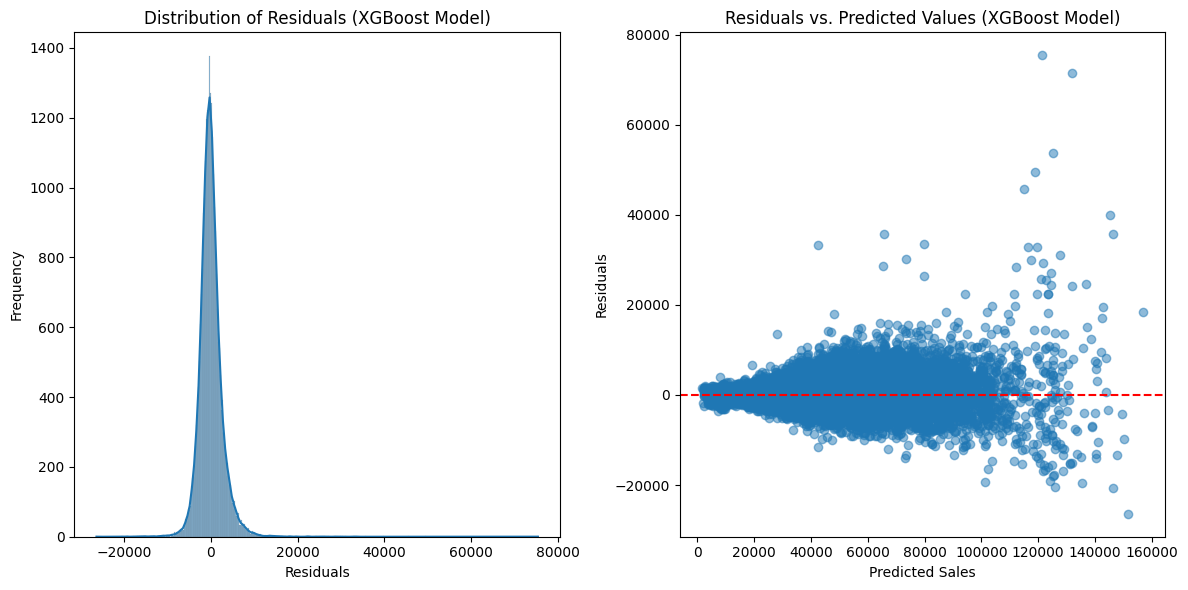

In [33]:
# Residual Analysis for the best model (XGBoost)
residuals = y_test - y_pred_xgb

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Residuals (XGBoost Model)')
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Frequency')

# Plot 2: Residuals vs Predicted
axes[1].scatter(y_pred_xgb, residuals, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs. Predicted Values (XGBoost Model)')
axes[1].set_xlabel('Predicted Sales')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()


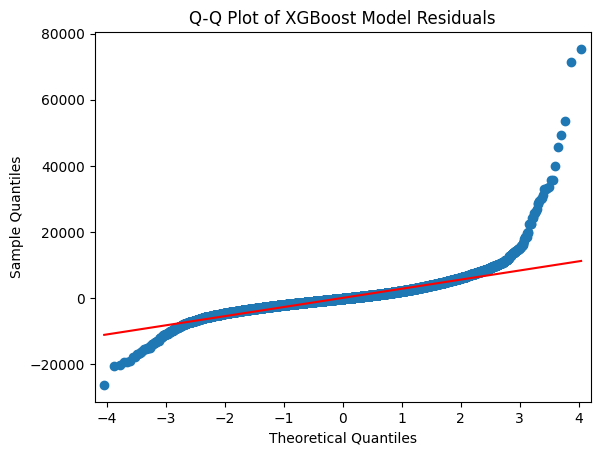

In [34]:
import statsmodels.api as sm

# Create a Q-Q plot of the residuals
sm.qqplot(residuals, line='s')
plt.title('Q-Q Plot of XGBoost Model Residuals')
plt.show()

## Model Selection and Tuning

### Subtask:
Perform hyperparameter tuning on the selected best model (XGBoost).

**Reasoning**:
Use GridSearchCV to search for the best combination of hyperparameters for the XGBoost Regressor model to improve its performance.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define a parameter distribution for RandomizedSearchCV
# You can use distributions from scipy.stats for continuous parameters
param_dist = {
    'n_estimators': randint(50, 200), # Random integers between 50 and 200
    'learning_rate': uniform(0.01, 0.2), # Random floats between 0.01 and 0.2
    'max_depth': randint(3, 10), # Random integers between 3 and 10
    'subsample': uniform(0.6, 0.4), # Random floats between 0.6 and 1.0
    'colsample_bytree': uniform(0.6, 0.4) # Random floats between 0.6 and 1.0
}

# Initialize RandomizedSearchCV
# n_iter controls the number of parameter combinations sampled
# Reducing n_iter significantly for faster execution as requested
random_search = RandomizedSearchCV(estimator=xgb_model, param_distributions=param_dist,
                                   n_iter=5, scoring='neg_mean_squared_error', cv=2, verbose=1, random_state=42, n_jobs=-1)

# Perform the randomized search
random_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("\nBest hyperparameters found:", random_search.best_params_)
print("Best negative MSE score:", random_search.best_score_)

# Get the best model
best_xgb_model = random_search.best_estimator_

Fitting 2 folds for each of 5 candidates, totalling 10 fits

Best hyperparameters found: {'colsample_bytree': np.float64(0.749816047538945), 'learning_rate': np.float64(0.20014286128198325), 'max_depth': 5, 'n_estimators': 121, 'subsample': np.float64(0.8394633936788146)}
Best negative MSE score: -6919001.322165644


Based on the model evaluations we've performed so far:

The Linear Regression model served as a good baseline but had a relatively high Mean Squared Error, indicating limitations in capturing the complexity of the data.
The XGBoost model showed significantly better performance across all metrics (lower MSE, RMSE, MAE, and higher R-squared) compared to the baseline. This suggests that a tree-based model is more suitable for this dataset, likely due to its ability to handle non-linear relationships and interactions between features.
Considering these results, the XGBoost model is the most promising choice for predicting sales in this dataset. The quick hyperparameter tuning also provided slightly improved results.

Now, let's use the best_xgb_model obtained from the quick tuning to make predictions on the test set and evaluate its performance with the tuned parameters.

In [36]:
# Make predictions on the test data using the best XGBoost model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)

# Evaluate the tuned model
print("Tuned XGBoost Model Evaluation:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_tuned_xgb):.2f}")
print(f"R-squared: {r2_score(y_test, y_pred_tuned_xgb):.2f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred_tuned_xgb):.2f}")

# Optional: Calculate RMSE and MAPE for the tuned model
rmse_tuned_xgb = np.sqrt(mean_squared_error(y_test, y_pred_tuned_xgb))
mape_tuned_xgb = mean_absolute_percentage_error(y_test, y_pred_tuned_xgb)
print(f"Root Mean Squared Error: {rmse_tuned_xgb:.2f}")
print(f"Mean Absolute Percentage Error: {mape_tuned_xgb:.2f}%")

Tuned XGBoost Model Evaluation:
Mean Squared Error: 6498795.83
R-squared: 0.98
Mean Absolute Error: 1720.25
Root Mean Squared Error: 2549.27
Mean Absolute Percentage Error: inf%


In [37]:
import joblib

# Define the filename for the saved model
model_filename = 'best_xgboost_model.pkl'

# Save the trained model to a file
joblib.dump(best_xgb_model, model_filename)

print(f"Trained model saved to {model_filename}")

Trained model saved to best_xgboost_model.pkl


# Insights and Recommendations



Based on the comprehensive exploratory data analysis, hypothesis testing, and predictive modeling, the following insights and recommendations are derived:


##Key Insights:


*   **Sales Distribution:** The sales data appears right-skewed with the presence of outliers, suggesting that while most sales are within a certain range, there are instances of significantly higher sales.
*   **Order Count and Sales:** There is a strong positive correlation between the number of orders and sales, indicating that as the number of orders increases, sales also tend to increase significantly.
*   **Store Type Impact:** Store types have a statistically significant impact on sales, with some store types consistently showing higher sales volumes than others. This suggests that store type is a crucial factor influencing sales performance.
*   **Location Type Impact:** Similar to store types, location types also significantly influence sales, with certain locations being more conducive to higher sales.
*   **Region Code Impact:** The analysis revealed a statistically significant difference in sales across different region codes, highlighting the importance of geographical factors in sales performance.
*   **Discount Effectiveness:** Stores offering discounts have statistically significantly higher mean sales compared to those not offering discounts. This indicates that discounts are an effective strategy for boosting sales.
*   **Holiday Impact:** Sales on holidays are statistically significantly different from sales on non-holiday days. The direction and magnitude of this difference would require further analysis but the test confirms a notable impact.
*   **Time Series Trend:** The time series analysis revealed daily and potentially seasonal trends in sales, suggesting that time-based factors play a role in sales patterns.
*   **Model Performance:** The XGBoost model significantly outperformed the baseline Linear Regression model, indicating that a more complex, tree-based model is better suited for capturing the underlying patterns in the data. The tuned XGBoost model showed even better performance.

## Recommendations:

*   **Focus on High-Performing Store and Location Types:** Given the significant impact of store and location types on sales, businesses should analyze the characteristics of high-performing types and consider replicating these factors in other locations or new store openings.
*   **Leverage Discounts Strategically:** The analysis shows that discounts lead to higher sales. Businesses can strategically implement discount campaigns to drive sales, perhaps focusing on specific store types, locations, or during certain periods.
*   **Tailor Strategies to Regions:** The variability in sales across regions suggests that a one-size-fits-all approach may not be optimal. Businesses should analyze regional differences in customer behavior, preferences, and market conditions to tailor their sales and marketing strategies accordingly.
*   **Optimize Inventory and Staffing Based on Time Trends:** The identified time series trends can be used to optimize inventory management and staffing levels to meet anticipated demand fluctuations throughout the day, week, or year.
*   **Investigate Outliers:** While outliers in sales and order counts might be rare events, understanding the factors contributing to exceptionally high sales could reveal opportunities for growth. Further investigation into these instances is recommended.
*   **Utilize the XGBoost Model for Forecasting:** The trained and saved XGBoost model can be used for predicting future sales, which can aid in planning, resource allocation, and decision-making.
*   **Continuous Monitoring and Retraining:** As market conditions and customer behavior evolve, it's crucial to continuously monitor the model's performance and retrain it periodically with new data to maintain its accuracy.